---
---
# MBA - 2026
## Dirección Financiera

### Profesor Fernando Díaz H.
---

# 📈 Beta y Retorno Esperado: ¿Existe una Relación Positiva?

El **CAPM** (*Capital Asset Pricing Model*) predice que, en equilibrio, el retorno esperado de un activo depende linealmente de su riesgo sistemático o **beta** ($\beta$):

$$E\left[\widetilde{r}_{i}\right]=r_{f}+\beta_{i}\left(E\left[\widetilde{r}_{M}\right]-r_{f}\right)$$

donde:

* $E\left[\widetilde{r}_{i}\right]$ es el retorno esperado del activo $i$;
* $r_{f}$ es la tasa libre de riesgo;
* $\beta_{i}$ mide la sensibilidad del activo frente al mercado;
* $E\left[\widetilde{r}_{M}\right]-r_{f}$ es la prima de riesgo del mercado.

Esta relación —conocida como la **Línea de Mercado de Valores** (*Security Market Line*, SML)— predice una **relación positiva** entre riesgo sistemático y retorno esperado: activos con mayor beta deberían, en promedio, ofrecer un mayor retorno esperado.

En este notebook contrastaremos esta predicción con datos reales: cada grupo del curso estimó, para un conjunto de acciones, su beta y su retorno esperado a 1 año. Combinando las estimaciones de todos los grupos, graficaremos la relación entre ambas variables —con el beta en el eje horizontal— y ajustaremos una línea de tendencia para evaluar si, en promedio, se observa la relación positiva que predice la teoría.

> ⚠️ **Advertencia metodológica:** este ejercicio **no** es una prueba rigurosa del CAPM. Los retornos esperados fueron estimados subjetivamente por cada grupo (no son retornos de equilibrio observados en el mercado), la muestra es pequeña, y cada grupo pudo haber usado supuestos y horizontes distintos. El objetivo es puramente ilustrativo: visualizar si, con datos reales generados por el curso, se aprecia la dirección cualitativa que predice la teoría.

## 📦 Cargando las librerías

Antes de comenzar el análisis, cargaremos los paquetes de **Python** que utilizaremos a lo largo del notebook:

* **`pandas`**: lectura del archivo Excel y transformación de datos.
* **`numpy`**: cálculos numéricos (ajuste de la línea de tendencia).
* **`matplotlib`**: construcción del gráfico.
* **`openpyxl`**: motor utilizado por `pandas` para leer archivos `.xlsx`.

> 💡 Las librerías deben instalarse una sola vez, pero deben importarse cada vez que se inicia una nueva sesión de Python.

In [1]:
%%capture
%pip install openpyxl

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 📥 Cargando los datos

Los datos fueron recopilados por los grupos del curso en el archivo `Betas y Retorno.xlsx` (sección [Excel Files](../../Excel%20Files/excel_files/) del sitio), donde cada grupo registró, para cinco acciones:

* el **sector** de la empresa;
* el símbolo bursátil (**`Empresa`**);
* su **beta** ($\beta$);
* su **retorno esperado a 1 año**.

El archivo tiene una fila en blanco y dos filas de encabezado (la segunda solo identifica a los integrantes de cada grupo), por lo que omitimos las primeras tres filas al leerlo. Además, algunos grupos registraron el retorno esperado como decimal (por ejemplo, `0.41`) y otros como texto con el símbolo de porcentaje (por ejemplo, `"9.03%"`), por lo que estandarizamos ambos formatos a un decimal consistente.

In [3]:
ruta_excel = "../Excel Files/Betas y Retorno.xlsx"

datos = pd.read_excel(ruta_excel, sheet_name="Hoja 1", header=None, skiprows=3)
datos = datos.iloc[:, :4]
datos.columns = ["Sector", "Empresa", "Beta", "RetornoEsperado"]

def a_decimal(x):
    if isinstance(x, str) and x.strip().endswith("%"):
        return float(x.strip().rstrip("%")) / 100
    return float(x)

datos["RetornoEsperado"] = datos["RetornoEsperado"].apply(a_decimal)
datos["Beta"] = datos["Beta"].astype(float)

print(f"Número de acciones: {len(datos)}")
datos

Número de acciones: 25


,Sector,Empresa,Beta,RetornoEsperado
0,Tecnología,MSFT,1.130,0.4115
1,Consumo ciclico,AMZN,1.461,0.2639
2,Consumo básico,PG,0.380,0.1030
3,Salud,ABBV,0.283,0.0409
4,Consumo no ciclico,KO,0.349,0.0677
5,Salud,JNJ,0.230,0.0576
6,Energético,CVX,0.470,0.3529
7,Consumo Cíclico,MCD,0.410,0.1895
8,Tecnología y Servicios de Telecomunicaciones,VZ,0.240,0.2868
9,Financiero,JPM,1.050,0.0498


In [4]:
tabla = datos[["Sector", "Empresa", "Beta", "RetornoEsperado"]].copy()
tabla["RetornoEsperado"] = (tabla["RetornoEsperado"] * 100).round(2)
tabla = tabla.rename(columns={"RetornoEsperado": "Retorno Esperado (%)"})
tabla.sort_values("Beta").style.format({"Beta": "{:.2f}", "Retorno Esperado (%)": "{:.2f}"}).hide(axis="index")

Sector,Empresa,Beta,Retorno Esperado (%)
Energético,XOM,0.16,9.03
Salud,JNJ,0.23,5.76
Tecnología y Servicios de Telecomunicaciones,VZ,0.24,28.68
Salud,ABBV,0.28,4.09
Consumo Básico,BF.B,0.34,8.71
Consumo no ciclico,KO,0.35,6.77
Consumo básico,PG,0.38,10.30
Consumo Cíclico,MCD,0.41,18.95
Energético,CVX,0.47,35.29
Salud,LLY,0.51,7.75


## 📊 Relación entre Beta y Retorno Esperado

A continuación, graficaremos cada acción como un punto en el plano beta-retorno, con el **beta en el eje horizontal** y el **retorno esperado en el eje vertical**.

Para evaluar la relación entre ambas variables, ajustaremos una **línea de tendencia** mediante una regresión lineal simple:

$$E\left[\widetilde{r}_{i}\right]=a+b\,\beta_{i}+\varepsilon_{i}$$

Si la teoría del CAPM se cumpliera exactamente y los datos no tuvieran ruido, esperaríamos:

* una pendiente $b$ positiva, análoga a la prima de riesgo del mercado $E\left[\widetilde{r}_{M}\right]-r_{f}$;
* un intercepto $a$ cercano a la tasa libre de riesgo $r_{f}$.

En la práctica, con datos reales —y especialmente con estimaciones subjetivas como las de este ejercicio— es normal observar una relación positiva pero **ruidosa**, no una línea perfecta.

In [5]:
beta = datos["Beta"].to_numpy()
retorno = datos["RetornoEsperado"].to_numpy()

pendiente, intercepto = np.polyfit(beta, retorno, 1)
r = np.corrcoef(beta, retorno)[0, 1]

print(f"Línea de tendencia: Retorno Esperado = {intercepto*100:.2f}% + {pendiente*100:.2f}% x Beta")
print(f"Correlación (r):     {r:.3f}")
print(f"R-cuadrado:          {r**2:.3f}")

Línea de tendencia: Retorno Esperado = 2.52% + 22.92% x Beta
Correlación (r):     0.529
R-cuadrado:          0.280


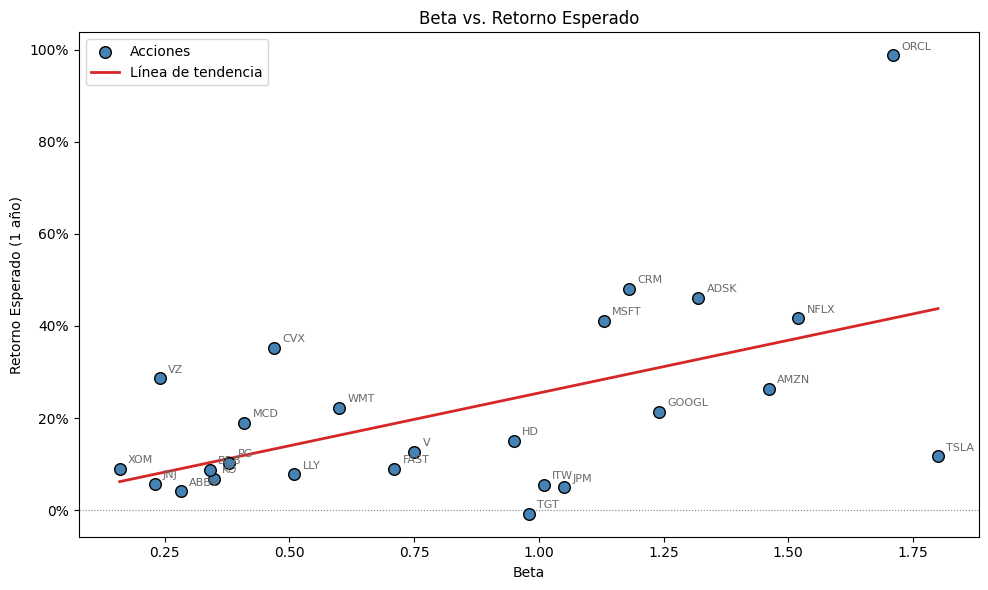

In [6]:
beta_grid = np.linspace(beta.min(), beta.max(), 100)
tendencia = intercepto + pendiente * beta_grid

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(beta, retorno, s=70, color="steelblue", edgecolor="black", zorder=3, label="Acciones")
ax.plot(beta_grid, tendencia, color="#d62728", linewidth=2, label="Línea de tendencia")

for _, fila in datos.iterrows():
    ax.annotate(fila["Empresa"], (fila["Beta"], fila["RetornoEsperado"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8, color="dimgray")

ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax.yaxis.set_major_formatter(lambda x, _: f"{x*100:.0f}%")
ax.set_xlabel("Beta")
ax.set_ylabel("Retorno Esperado (1 año)")
ax.set_title("Beta vs. Retorno Esperado")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 🧭 Interpretación

La línea de tendencia tiene **pendiente positiva**, consistente con la predicción cualitativa del CAPM: en este conjunto de datos, las acciones con mayor beta tienden a exhibir, en promedio, un mayor retorno esperado.

Sin embargo, el ajuste está lejos de ser perfecto —el $R^{2}$ es moderado—, lo cual es esperable dado que:

* los retornos esperados fueron **estimaciones subjetivas** de cada grupo, no expectativas de mercado en equilibrio;
* distintos grupos pudieron usar supuestos, fuentes y horizontes de estimación distintos;
* la muestra es pequeña (unas pocas decenas de acciones) y sensible a valores atípicos —por ejemplo, alguna acción con un retorno esperado inusualmente alto puede influir notablemente en el ajuste—.

> 💡 **Idea central:** este ejercicio ilustra la **dirección** de la relación riesgo-retorno predicha por el CAPM, pero no debe interpretarse como una estimación confiable de la prima de riesgo de mercado ni como una prueba estadística formal de la teoría.